# Exercises 4 – NOx pollution in Boston

In [40]:
import matplotlib.pyplot as plt

# Plotting style
import seaborn as sns
sns.set_style('darkgrid')
sns.set_theme(font_scale=1.)

import pandas as pd
import numpy as np
import statsmodels.api as sm

The overall question here is how we can analyse whether an area in Boston has too high levels of NOx. 

We will use the data set Boston, which in R is included in the ISLR2 library. It will also be uploaded to DTU learn.

>Load data

The dataset contains housing values in 506 suburbs of Boston and has 13 variables. The table below gives a brief description of each variable.

| Variabel | Beskrivelse |
|---|---|
| crim | per capita crime rate by town |
| zn | proportion of residential land zoned for lots over 25,000 sq.ft. |
| indus | proportion of non-retail business acres per town |
| chas | Charles River dummy variable (1 if tract bounds river; 0 otherwise) |
| nox | nitrogen oxides concentration (parts per 10 million) |
| rm | average number of rooms per dwelling |
| age | proportion of owner-occupied units built prior to 1940 |
| dis | weighted mean of distances to five Boston employment centres |
| rad | index of accessibility to radial highways |
| tax | full-value property-tax rate per $10,000 |
| ptratio | pupil-teacher ratio by town |
| lstat | lower status of the population (percent) |
| medv | median value of owner-occupied homes in $1000s |

**A more intuitive explanation of the variables**

I checked the data values as well, so the interpretations below match the actual scale of the dataset: `crim` ranges from about 0.01 to 88.98, `zn` from 0 to 100, `indus` from 0.46 to 27.74, `nox` from 0.385 to 0.871, `rm` from 3.56 to 8.78, `age` from 2.9 to 100, `dis` from 1.13 to 12.13, `rad` from 1 to 24, `tax` from 187 to 711, `ptratio` from 12.6 to 22.0, `lstat` from 1.73 to 37.97, and `medv` from 5 to 50. `chas` is binary and therefore only takes the values 0 and 1.

- `crim`: This is a continuous variable measured as crime rate per person in each town. In the data it is very right-skewed, meaning most towns have low crime rates but a few towns have extremely high values.
- `zn`: This is a percentage, so it should be read as a share of land zoned for large residential lots. A value of 0 means no such zoning, while 100 means the whole area is zoned that way. In the dataset many towns have `zn = 0`.
- `indus`: Also a share/percentage. It describes how much of the land is used for non-retail business. Higher values indicate a more industrial or commercial area. (Fortæller om et område er et industrikvarter eller boligkvarter)
- `chas`: A dummy variable. `1` means the area borders the Charles River and `0` means it does not. It is not a quantity with a unit; it is simply a yes/no indicator.
- `nox`: Air pollution measured as nitrogen oxides concentration. The values are around 0.4 to 0.9 parts per 10 million, so higher values mean worse air quality.
- `rm`: Average number of rooms per dwelling. This is a housing-size variable, and values between about 3.6 and 8.8 mean the areas range from small homes to fairly large homes.
- `age`: Percentage of owner-occupied houses (ejerboliger) built before 1940. A high value means an older housing stock.
- `dis`: A distance measure to Boston employment centres. Higher values mean the town is, on average, farther away from major job centres.
- `rad`: An accessibility index to radial highways. It is an index rather than a direct physical unit, so the numbers should be interpreted comparatively: larger values mean better highway access.
- `tax`: Property tax rate per $10,000 of full property value. This is a financial burden variable, and the data show substantial variation across towns. (Variablen angiver, hvor mange dollars man betaler i skat for hver $10.000 af boligens værdi. Hvis TAX er 200: Så betaler du 200 i skat for hver 10.000 huset er værd. Det svarer til en skattesats på 2%.)
- `ptratio`: Number of pupils per teacher in town schools. Higher values usually indicate more pressure on the school system and potentially fewer resources per pupil.
- `lstat`: Percentage of the population with lower socioeconomic status. Higher values are typically associated with less affluent neighbourhoods.
- `medv`: Median house value in thousands of dollars. For example, `medv = 25` means about $25,000. In this dataset the variable is capped at 50, so very expensive houses are not shown above that level.

*Variable specification for Boston Housing dataset*

In [41]:
df_boston = pd.read_csv("Boston.csv")

In [42]:
df_boston.head()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


>a) Create a dummy (nox_dum) for when the nox variable is above 0.60 parts per 10 million.
Calculate descriptive statistics and discuss which variables are likely to explain nox_dum
and whether you could get issues with multicollinearity.

In [43]:
df_boston["nox_dum"] = (df_boston["nox"] > 0.6).astype(int)

In [44]:
df_boston.describe()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv,nox_dum
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,253.500000,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806,0.326087
std,146.213884,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104,0.469243
min,1.000000,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000,0.000000
25%,127.250000,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000,0.000000
50%,253.500000,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000,0.000000
75%,379.750000,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000,1.000000
max,506.000000,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000,1.000000


Class balance for nox_dum


,count,share_pct
nox_dum,,
0,341,67.39
1,165,32.61


Group summary by nox_dum (0 = low NOx, 1 = high NOx)


crim                     zn                  indus                \
          mean median     std    mean median     std    mean median    std   
nox_dum                                                                      
0        1.002  0.117   3.896  16.276    0.0  26.882   7.744    6.2  5.141   
1        9.012  5.581  12.364   1.212    0.0   4.787  18.149   18.1  4.089   

          chas  ...      tax ptratio                 lstat                \
          mean  ...      std    mean median    std    mean median    std   
nox_dum         ...                                                        
0        0.059  ...  114.853  18.264   18.4  1.869  10.283   9.28  5.564   
1        0.091  ...  137.537  18.852   20.2  2.638  17.552  17.11  7.551   

           medv                 
           mean median     std  
nox_dum                         
0        24.470   22.6   7.656  
1        18.528   15.4  10.725  

[2 rows x 36 columns]

Variables ranked by absolute standardized mean difference


,variable,mean_dum0,mean_dum1,std_mean_diff
2,indus,7.744,18.149,2.240
8,tax,327.853,574.364,1.946
6,dis,4.704,1.916,-1.940
5,age,56.626,93.269,1.868
7,rad,5.959,16.970,1.433
10,lstat,10.283,17.552,1.096
0,crim,1.002,9.012,0.874
1,zn,16.276,1.212,-0.780
11,medv,24.470,18.528,-0.638
4,rm,6.377,6.093,-0.393


Correlation matrix among explanatory variables


,crim,zn,indus,chas,rm,age,dis,rad,tax,ptratio,lstat,medv
crim,1.00,-0.20,0.41,-0.06,-0.22,0.35,-0.38,0.63,0.58,0.29,0.46,-0.39
zn,-0.20,1.00,-0.53,-0.04,0.31,-0.57,0.66,-0.31,-0.31,-0.39,-0.41,0.36
indus,0.41,-0.53,1.00,0.06,-0.39,0.64,-0.71,0.60,0.72,0.38,0.60,-0.48
chas,-0.06,-0.04,0.06,1.00,0.09,0.09,-0.10,-0.01,-0.04,-0.12,-0.05,0.18
rm,-0.22,0.31,-0.39,0.09,1.00,-0.24,0.21,-0.21,-0.29,-0.36,-0.61,0.70
age,0.35,-0.57,0.64,0.09,-0.24,1.00,-0.75,0.46,0.51,0.26,0.60,-0.38
dis,-0.38,0.66,-0.71,-0.10,0.21,-0.75,1.00,-0.49,-0.53,-0.23,-0.50,0.25
rad,0.63,-0.31,0.60,-0.01,-0.21,0.46,-0.49,1.00,0.91,0.46,0.49,-0.38
tax,0.58,-0.31,0.72,-0.04,-0.29,0.51,-0.53,0.91,1.00,0.46,0.54,-0.47
ptratio,0.29,-0.39,0.38,-0.12,-0.36,0.26,-0.23,0.46,0.46,1.00,0.37,-0.51


VIF table (multicollinearity diagnostics)


,variable,VIF
8,tax,9.19
7,rad,7.47
6,dis,3.92
2,indus,3.71
11,medv,3.59
10,lstat,3.56
5,age,2.88
1,zn,2.35
4,rm,2.21
0,crim,1.80


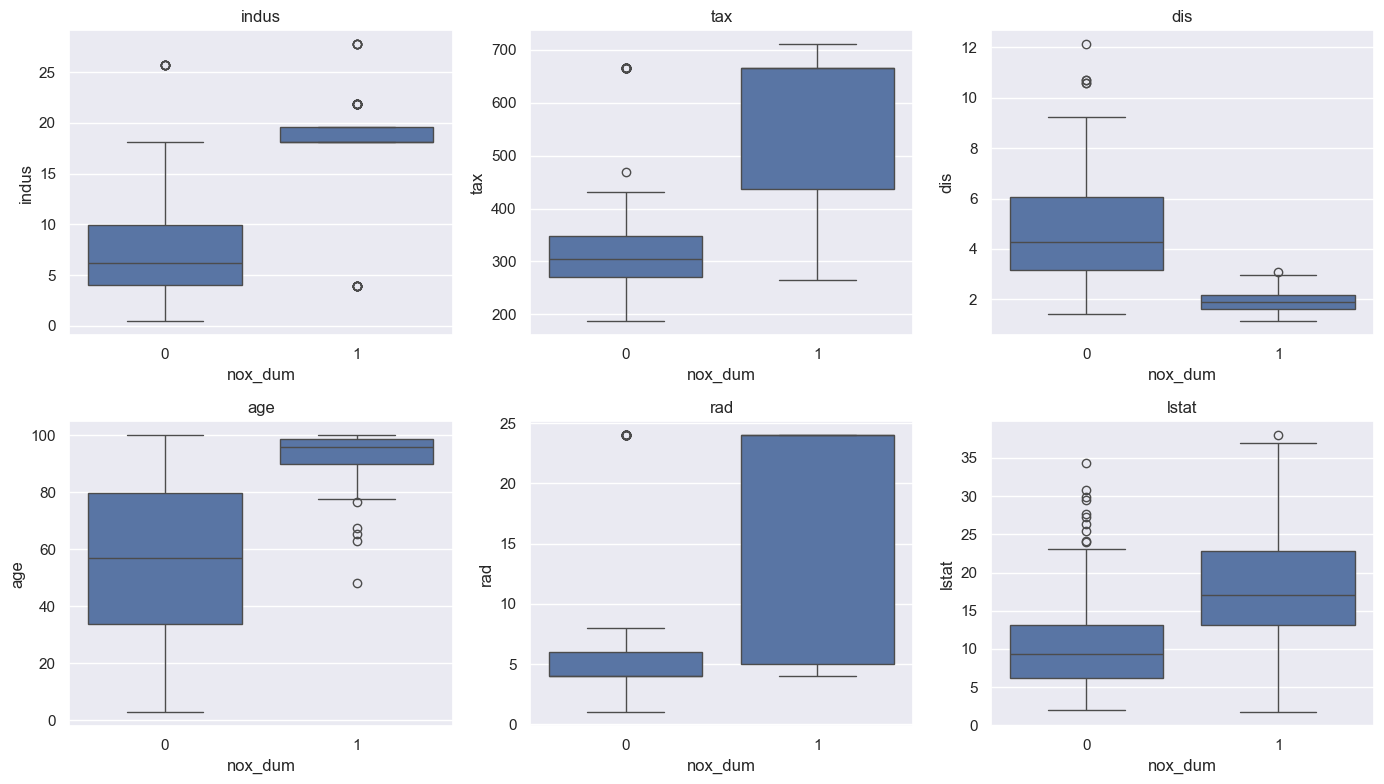

In [45]:
# Descriptive statistics for nox_dum and candidate explanatory variables
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1) How many observations are in each class (nox_dum = 0/1)
print("Class balance for nox_dum")
class_count = df_boston["nox_dum"].value_counts().sort_index()
class_share = (df_boston["nox_dum"].value_counts(normalize=True).sort_index() * 100).round(2)
class_table = pd.DataFrame({"count": class_count, "share_pct": class_share})
display(class_table)

# 2) Compare means/medians by nox_dum group (this is key descriptive evidence)
X_cols = ["crim", "zn", "indus", "chas", "rm", "age", "dis", "rad", "tax", "ptratio", "lstat", "medv"]

group_summary = (
    df_boston.groupby("nox_dum")[X_cols]
    .agg(["mean", "median", "std"])
    .round(3)
)
print("Group summary by nox_dum (0 = low NOx, 1 = high NOx)")
display(group_summary)

# 3) Standardized mean difference to rank strongest separators between groups
rows = []
for col in X_cols:
    g0 = df_boston.loc[df_boston["nox_dum"] == 0, col].dropna()
    g1 = df_boston.loc[df_boston["nox_dum"] == 1, col].dropna()
    pooled_sd = np.sqrt((g0.var(ddof=1) + g1.var(ddof=1)) / 2)
    smd = (g1.mean() - g0.mean()) / pooled_sd if pooled_sd > 0 else np.nan
    rows.append({"variable": col, "mean_dum0": g0.mean(), "mean_dum1": g1.mean(), "std_mean_diff": smd})

smd_table = pd.DataFrame(rows).sort_values("std_mean_diff", key=lambda s: s.abs(), ascending=False)
print("Variables ranked by absolute standardized mean difference")
display(smd_table.round(3))

# 4) Correlation matrix among explanatory variables (multicollinearity first check)
corr = df_boston[X_cols].corr(numeric_only=True)
print("Correlation matrix among explanatory variables")
display(corr.round(2))

# 5) VIF (Variance Inflation Factor): values > 5 (or > 10) indicate concern
X_vif = df_boston[X_cols].copy()
# Keep a constant for correct VIF computation context
X_vif = X_vif.assign(const=1.0)

vif_table = pd.DataFrame({
    "variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_table = vif_table[vif_table["variable"] != "const"].sort_values("VIF", ascending=False)
print("VIF table (multicollinearity diagnostics)")
display(vif_table.round(2))

# 6) Optional visual overview: boxplots for top 6 separators
top6 = smd_table.head(6)["variable"].tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, var in zip(axes.flatten(), top6):
    sns.boxplot(data=df_boston, x="nox_dum", y=var, ax=ax)
    ax.set_title(var)
    ax.set_xlabel("nox_dum")
plt.tight_layout()
plt.show()

Man kan se at de variable der er likely til at explain nox_dum er:
- `indus`: Fortæller om et område er et industrikvarter eller boligkvarter

- `tax`: Variablen angiver, hvor mange dollars man betaler i skat for hver $10.000 af boligens værdi. Hvis TAX er 200: Så betaler du 200 i skat for hver 10.000 huset er værd. Det svarer til en skattesats på 2%


- `dis`: A distance measure to Boston employment centres. Higher values mean the town is, on average, farther away from major job centres.


- `age`: Percentage of owner-occupied houses (ejerboliger) built before 1940. A high value means an older housing stock.


- `rad`: An accessibility index to radial highways. It is an index rather than a direct physical unit, so the numbers should be interpreted comparatively: larger values mean better highway access.

Tanker omkring multikollinearitet:


Ud fra korrelationsmatricen kan man se at:
* `rad` og `tax` er ekstremt stærkt korrelerede med en værdi på **0,91**. Tax stiger når du har bedre access til highway

* `dis` og `age` er stærkt korrelerede med en værdi på **-0,75**, hvilket indikerer, at nyere huse typisk ligger længere væk fra centrum.

* `indus` og `tax` er korrelerede med en værdi på **0,72**, hvilket tyder på en sammenhæng mellem industriarealer og skattesatser.

* `dis` og `indus` er korrelerede med en værdi på **-0,71** (bemærk det negative fortegn, da industrien aftager med afstanden).

* `indus` og `age` er korrelerede med en værdi på **0,64**. Flere boligere af ældrere dato ved områder med mere industri.

Ud fra VIF-tabel kan man se:
* `Tax` (9.19) og `Rad` (7.47): Disse to har de højeste værdier. Det bekræfter, at de er stærkt multikollineære. I Boston hænger ejendomsskatten og adgangen til motorveje ekstremt tæt sammen

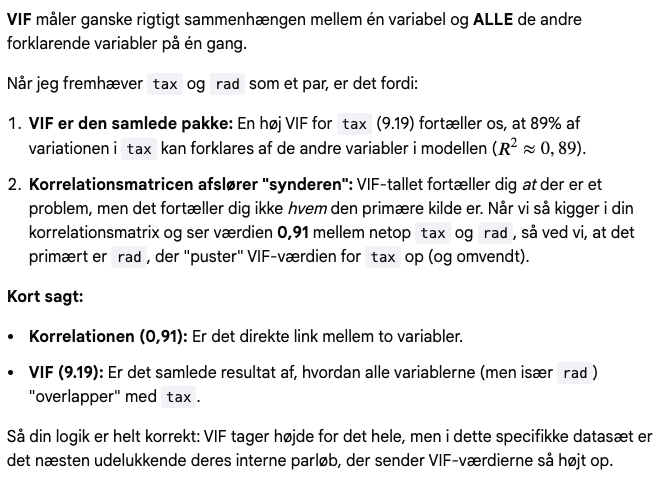

# a) Deskriptiv statistik

In [46]:
df = pd.read_csv("Boston.csv")

display(df.head())

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


Laver den afhængige variabel om til dummy 

0: nox mindre end 0.6,  

1: nox større end 0.6

In [47]:
df["nox_dum"] = (df["nox"] > 0.6).astype(int)

df.describe()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv,nox_dum
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,253.500000,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806,0.326087
std,146.213884,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104,0.469243
min,1.000000,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000,0.000000
25%,127.250000,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000,0.000000
50%,253.500000,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000,0.000000
75%,379.750000,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000,1.000000
max,506.000000,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000,1.000000


crim: skæv fordeling
zn, chas: mange 0 værdier

In [48]:
df.groupby("nox_dum").mean()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
nox_dum,,,,,,,,,,,,,,
0,213.894428,1.001527,16.275660,7.743578,0.058651,0.487395,6.377364,56.626100,4.704150,5.958944,327.853372,18.263930,10.282522,24.470381
1,335.351515,9.011650,1.212121,18.149394,0.090909,0.693782,6.092994,93.269091,1.916222,16.969697,574.363636,18.851515,17.552182,18.528485


In [49]:
df.corr()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv,nox_dum
Unnamed: 0,1.000000,0.407407,-0.103393,0.399439,-0.003759,0.398736,-0.079971,0.203784,-0.302211,0.686002,0.666626,0.291074,0.258465,-0.226604,0.389792
crim,0.407407,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,0.455621,-0.388305,0.436979
zn,-0.103393,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,-0.412995,0.360445,-0.303076
indus,0.399439,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,0.603800,-0.483725,0.711751
chas,-0.003759,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,-0.053929,0.175260,0.059595
nox,0.398736,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,0.590879,-0.427321,0.835758
rm,-0.079971,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,-0.613808,0.695360,-0.189917
age,0.203784,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,0.602339,-0.376955,0.610841
dis,-0.302211,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,-0.496996,0.249929,-0.621271
rad,0.686002,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,0.488676,-0.381626,0.593381


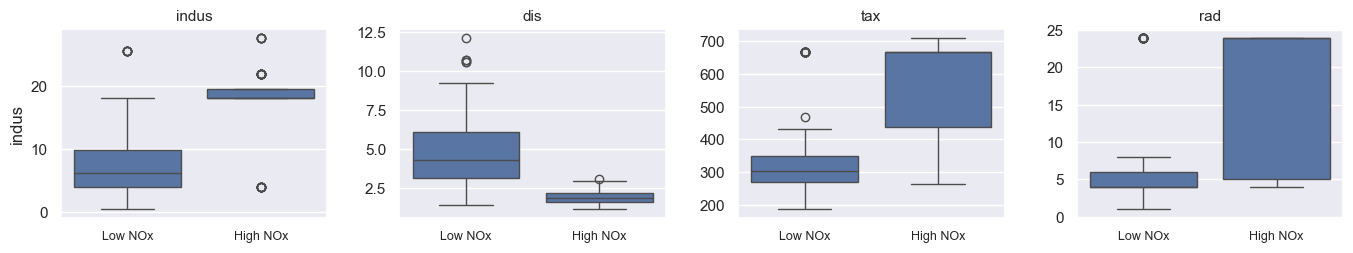

In [50]:

vars_to_plot = ["indus", "dis", "tax", "rad"]

plt.figure(figsize=(14, 3))  # bred og lav figur

for i, var in enumerate(vars_to_plot, 1):
    plt.subplot(1, 4, i)  # 1 række, 4 plots
    sns.boxplot(x="nox_dum", y=var, data=df)
    
    plt.title(var, fontsize=11)
    plt.xlabel("")  # fjerner x-label (nox_dum gentages ikke)
    plt.ylabel(var if i == 1 else "")  # kun første har y-label
    
    plt.xticks([0,1], ["Low NOx", "High NOx"], fontsize=9)

plt.tight_layout(pad=2)  # ekstra spacing
plt.savefig("boxplots_nox_dum.png", dpi=300)  # gemmer figuren
plt.show()

# b) Estimering af logistisk regressionsmodel 

In [68]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

target = "nox_dum"

predictors = [
    "zn",
    "indus",
    "chas",
    "rm",
    "age",
    "dis",
    "rad",
    "tax",
    "lstat",
    "medv"
]

df_clean = df.dropna(subset=[target] + predictors)

def mcfadden_adj_r2(model):
    ll_model = model.llf       # LL(beta_hat)
    ll_null = model.llnull     # LL(0)
    K = len(model.params)      # antal parametre inkl. konstant
    
    return 1 - ((ll_model - K) / ll_null)

def forward_selection_logit(df, target, predictors):
    remaining = set(predictors)
    selected = []
    current_score = -np.inf
    results = []

    while remaining:
        print(f"\nStep with selected: {selected}")
        scores_with_candidates = []

        for candidate in remaining:
            if selected:
                formula = f"{target} ~ " + " + ".join(selected + [candidate])
            else:
                formula = f"{target} ~ {candidate}"

            try:
                model = sm.Logit.from_formula(formula, data=df).fit(disp=False)
                score = mcfadden_adj_r2(model)

                scores_with_candidates.append((score, candidate))
                print(f"  Testing {candidate}: adjusted rho² = {score:.4f}")

            except Exception as e:
                print(f"  Testing {candidate}: FAILED ({e})")

        if not scores_with_candidates:
            break

        scores_with_candidates.sort()
        best_new_score, best_candidate = scores_with_candidates.pop()

        print(f"  Best candidate: {best_candidate} with adjusted rho² = {best_new_score:.4f}")

        if best_new_score > current_score:
            remaining.remove(best_candidate)
            selected.append(best_candidate)
            current_score = best_new_score
            results.append((selected.copy(), current_score))
        else:
            break

    return results

selection_results = forward_selection_logit(df_clean, target, predictors)

print("\nForward Selection Results:")
for i, (vars, adj_rho2) in enumerate(selection_results, 1):
    print(f"Step {i}: Variables: {vars}, adjusted rho²: {adj_rho2:.4f}")

if selection_results:
    final_vars = selection_results[-1][0]
    formula = f"{target} ~ " + " + ".join(final_vars)
    final_model = sm.Logit.from_formula(formula, data=df_clean).fit()

    print("\nFinal Model Summary:")
    print(final_model.summary())
    print("\nAdjusted rho²:", mcfadden_adj_r2(final_model))


Step with selected: []
  Testing indus: adjusted rho² = 0.4731
  Testing zn: adjusted rho² = 0.1124
  Testing rad: adjusted rho² = 0.2702
  Testing lstat: adjusted rho² = 0.1822
  Testing chas: adjusted rho² = -0.0036
  Testing tax: adjusted rho² = 0.3906
  Testing medv: adjusted rho² = 0.0802
  Testing dis: adjusted rho² = 0.6215
  Testing rm: adjusted rho² = 0.0237
  Testing age: adjusted rho² = 0.4472
  Best candidate: dis with adjusted rho² = 0.6215

Step with selected: ['dis']
  Testing indus: adjusted rho² = 0.6490
  Testing zn: adjusted rho² = 0.6193
  Testing rad: adjusted rho² = 0.6549
  Testing lstat: adjusted rho² = 0.6184
  Testing chas: adjusted rho² = 0.6221
  Testing tax: adjusted rho² = 0.6738
  Testing medv: adjusted rho² = 0.6193
  Testing rm: adjusted rho² = 0.6220
  Testing age: adjusted rho² = 0.6376
  Best candidate: tax with adjusted rho² = 0.6738

Step with selected: ['dis', 'tax']
  Testing indus: adjusted rho² = 0.6749
  Testing zn: adjusted rho² = 0.6847
  T

> LR-test

In [52]:
from scipy import stats

def lr_test(model_small, model_large):
    ll_small = model_small.llf
    ll_large = model_large.llf
    
    LR = 2 * (ll_large - ll_small)
    
    df = len(model_large.params) - len(model_small.params)
    
    p_value = stats.chi2.sf(LR, df)
    
    return LR, df, p_value


m4 = sm.Logit.from_formula("nox_dum ~ dis + tax + ptratio + indus", data=df_clean).fit()
m5 = sm.Logit.from_formula("nox_dum ~ dis + tax + ptratio + indus + rad", data=df_clean).fit()
m6 = sm.Logit.from_formula("nox_dum ~ dis + tax + ptratio + indus + rad + crim", data=df_clean).fit()
m7 = sm.Logit.from_formula("nox_dum ~ dis + tax + ptratio + indus + rad + crim + age", data=df_clean).fit()

Optimization terminated successfully.
         Current function value: 0.159926
         Iterations 10
Optimization terminated successfully.
         Current function value: 0.124751
         Iterations 13
Optimization terminated successfully.
         Current function value: 0.121622
         Iterations 14
Optimization terminated successfully.
         Current function value: 0.118911
         Iterations 14


In [53]:
#printer (LR-statistik, frihedsgrader, p-værdi)
print("Step 4 vs 5:", lr_test(m4, m5))
print("Step 5 vs 6:", lr_test(m5, m6))
print("Step 6 vs 7:", lr_test(m6, m7))

Step 4 vs 5: (35.59678928234925, 1, 2.4268721337744364e-09)
Step 5 vs 6: (3.166784523588376, 1, 0.07515026469004601)
Step 6 vs 7: (2.7441523911026167, 1, 0.09761082486771235)


Ud fra p-værdierne er de alle signifikante ved et p=0.15 niveau og den fulde model fra step 7 beholdes

# c) Ny model med interaktionsled og ikke-lineær led

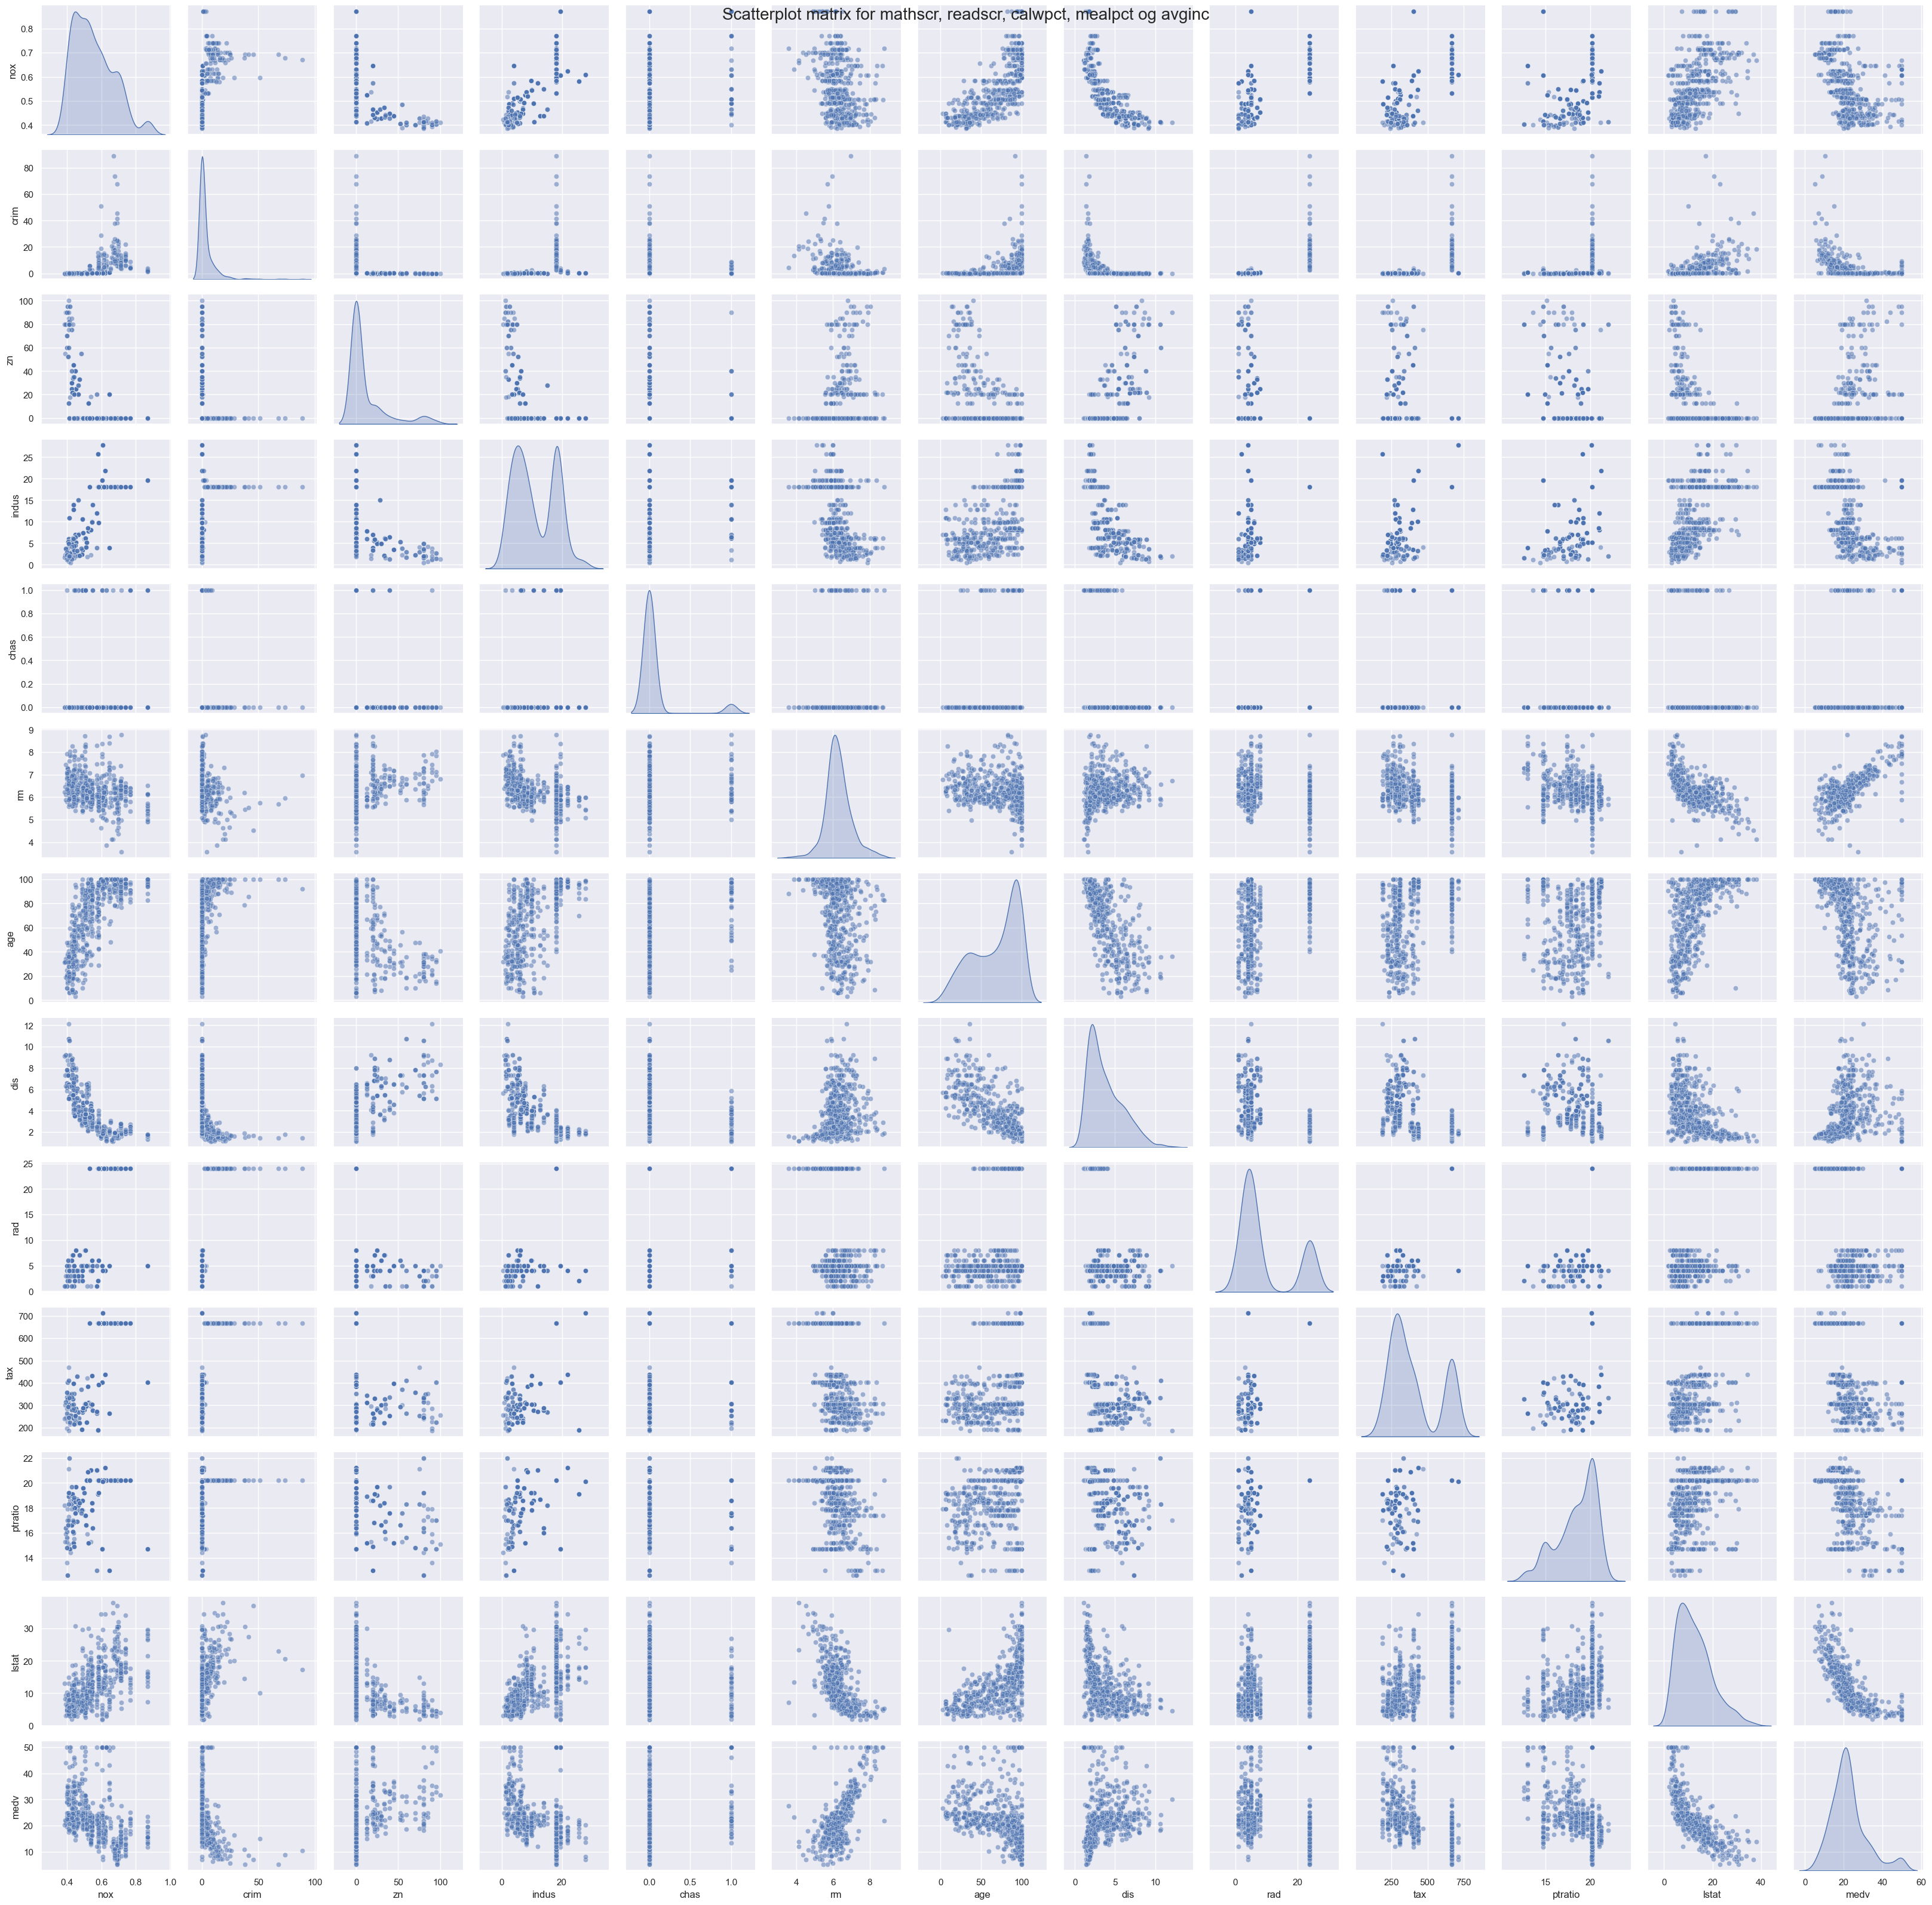

In [54]:
# Vælg de kolonner du vil kigge på
cols = ["nox",
    "crim",
    "zn",
    "indus",
    "chas",
    "rm",
    "age",
    "dis",
    "rad",
    "tax",
    "ptratio",
    "lstat",
    "medv"]

# Lav et pairplot
sns.pairplot(df[cols], diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle("Scatterplot matrix for mathscr, readscr, calwpct, mealpct og avginc", fontsize=20)
plt.tight_layout()
plt.show()

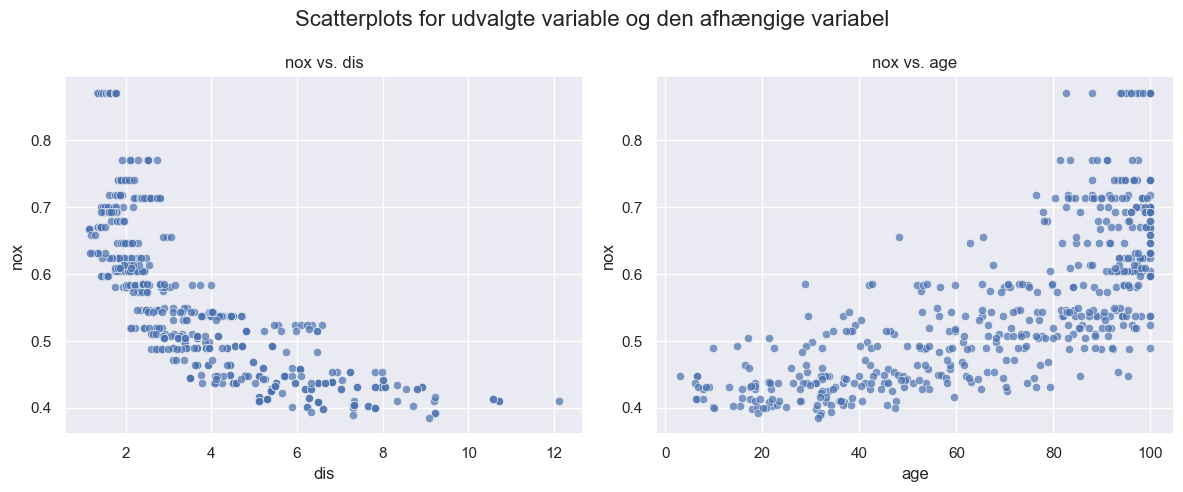

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(data=df, x="dis", y="nox", ax=axes[0], alpha=0.7)
axes[0].set_title("nox vs. dis")
axes[0].set_xlabel("dis")
axes[0].set_ylabel("nox")

sns.scatterplot(data=df, x="age", y="nox", ax=axes[1], alpha=0.7)
axes[1].set_title("nox vs. age")
axes[1].set_xlabel("age")
axes[1].set_ylabel("nox")

fig.suptitle("Scatterplots for udvalgte variable og den afhængige variabel", fontsize=16)
plt.tight_layout()
plt.show()

In [66]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

target = "nox_dum"

# Lav kvadrerede og interaktionsled først
df['age_squared'] = df['age'] ** 2
df['dis_squared'] = df['dis'] ** 2
df['indus_dis'] = df['indus'] * df['dis']
df['indus_tax'] = df['indus'] * df['tax']

predictors = [
    "crim",
    "zn",
    "indus",
    "chas",
    "rm",
    "age",
    "age_squared",
    "dis",
    "dis_squared",
    "rad",
    "tax",
    "ptratio",
    "lstat",
    "medv",
    "indus_dis",
    "indus_tax"
]

df_clean = df.dropna(subset=[target] + predictors)

def mcfadden_adj_r2(model):
    ll_model = model.llf
    ll_null = model.llnull
    K = len(model.params)
    
    return 1 - ((ll_model - K) / ll_null)

def forward_selection_logit(df, target, predictors):
    # Dependency map: hvis et kvadreret/interaktionsled vælges, skal parent-variablerne også være med
    dependencies = {
        'age_squared': ['age'],
        'dis_squared': ['dis'],
        'indus_dis': ['indus', 'dis'],
        'indus_tax': ['indus', 'tax']
    }
    
    remaining = set(predictors)
    selected = []
    current_score = -np.inf
    results = []

    while remaining:
        print(f"\nStep with selected: {selected}")
        scores_with_candidates = []

        for candidate in remaining:
            # Check om alle parent-variabler er valgt
            required_vars = dependencies.get(candidate, [])
            if any(var not in selected for var in required_vars):
                print(f"  Skipping {candidate}: missing parent variables {required_vars}")
                continue
            
            if selected:
                formula = f"{target} ~ " + " + ".join(selected + [candidate])
            else:
                formula = f"{target} ~ {candidate}"

            try:
                model = sm.Logit.from_formula(formula, data=df).fit(disp=False)
                score = mcfadden_adj_r2(model)

                scores_with_candidates.append((score, candidate))
                print(f"  Testing {candidate}: adjusted rho² = {score:.4f}")

            except Exception as e:
                print(f"  Testing {candidate}: FAILED ({e})")

        if not scores_with_candidates:
            break

        scores_with_candidates.sort()
        best_new_score, best_candidate = scores_with_candidates.pop()

        print(f"  Best candidate: {best_candidate} with adjusted rho² = {best_new_score:.4f}")

        if best_new_score > current_score:
            remaining.remove(best_candidate)
            selected.append(best_candidate)
            current_score = best_new_score
            results.append((selected.copy(), current_score))
        else:
            break

    return results

selection_results = forward_selection_logit(df_clean, target, predictors)

print("\nForward Selection Results:")
for i, (vars, adj_rho2) in enumerate(selection_results, 1):
    print(f"Step {i}: Variables: {vars}, adjusted rho²: {adj_rho2:.4f}")

if selection_results:
    final_vars = selection_results[-1][0]
    formula = f"{target} ~ " + " + ".join(final_vars)
    final_model = sm.Logit.from_formula(formula, data=df_clean).fit()

    print("\nFinal Model Summary:")
    print(final_model.summary())
    print("\nAdjusted rho²:", mcfadden_adj_r2(final_model))


Step with selected: []
  Testing indus: adjusted rho² = 0.4731
  Skipping indus_tax: missing parent variables ['indus', 'tax']
  Testing zn: adjusted rho² = 0.1124
  Skipping indus_dis: missing parent variables ['indus', 'dis']
  Testing rad: adjusted rho² = 0.2702
  Testing lstat: adjusted rho² = 0.1822
  Testing chas: adjusted rho² = -0.0036
  Skipping dis_squared: missing parent variables ['dis']
  Testing tax: adjusted rho² = 0.3906
  Testing medv: adjusted rho² = 0.0802
  Skipping age_squared: missing parent variables ['age']
  Testing dis: adjusted rho² = 0.6215
  Testing ptratio: adjusted rho² = 0.0070
  Testing crim: adjusted rho² = 0.2452
  Testing rm: adjusted rho² = 0.0237
  Testing age: adjusted rho² = 0.4472
  Best candidate: dis with adjusted rho² = 0.6215

Step with selected: ['dis']
  Testing indus: adjusted rho² = 0.6490
  Skipping indus_tax: missing parent variables ['indus', 'tax']
  Testing zn: adjusted rho² = 0.6193
  Skipping indus_dis: missing parent variables [

/opt/miniconda3/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/opt/miniconda3/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/miniconda3/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/opt/miniconda3/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/opt/miniconda3/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/opt/miniconda3/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: 

In [63]:
import statsmodels.formula.api as smf

formula = "nox_dum ~ dis + tax + ptratio + indus + rad  + crim + age"

# Logit
logit_model = smf.logit(formula, data=df_clean).fit()
print(logit_model.summary())

# OLS med samme dummy som afhængig variabel
ols_model = smf.ols(formula, data=df_clean).fit()
print(ols_model.summary())

Optimization terminated successfully.
         Current function value: 0.118911
         Iterations 14
                           Logit Regression Results                           
Dep. Variable:                nox_dum   No. Observations:                  506
Model:                          Logit   Df Residuals:                      498
Method:                           MLE   Df Model:                            7
Date:                Wed, 06 May 2026   Pseudo R-squ.:                  0.8117
Time:                        09:08:22   Log-Likelihood:                -60.169
converged:                       True   LL-Null:                       -319.47
Covariance Type:            nonrobust   LLR p-value:                7.981e-108
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     65.7824     15.272      4.307      0.000      35.850      95.715
dis           -2.2544      0

In [64]:
import statsmodels.formula.api as smf

formula = "nox_dum ~ dis + tax + ptratio + indus + rad  + chas + dis_squared + age"

# Logit
logit_model = smf.logit(formula, data=df_clean).fit()
print(logit_model.summary())

# OLS med samme dummy som afhængig variabel
ols_model = smf.ols(formula, data=df_clean).fit()
print(ols_model.summary())

Optimization terminated successfully.
         Current function value: 0.103401
         Iterations 20
                           Logit Regression Results                           
Dep. Variable:                nox_dum   No. Observations:                  506
Model:                          Logit   Df Residuals:                      497
Method:                           MLE   Df Model:                            8
Date:                Wed, 06 May 2026   Pseudo R-squ.:                  0.8362
Time:                        09:08:45   Log-Likelihood:                -52.321
converged:                       True   LL-Null:                       -319.47
Covariance Type:            nonrobust   LLR p-value:                3.045e-110
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept     238.3922    142.959      1.668      0.095     -41.802     518.586
dis             6.7128   

In [65]:
import statsmodels.formula.api as smf

formula = "nox_dum ~ dis + tax + ptratio + indus + rad  + dis_squared + age"

# Logit
logit_model = smf.logit(formula, data=df_clean).fit()
print(logit_model.summary())

# OLS med samme dummy som afhængig variabel
ols_model = smf.ols(formula, data=df_clean).fit()
print(ols_model.summary())

Optimization terminated successfully.
         Current function value: 0.106324
         Iterations 19
                           Logit Regression Results                           
Dep. Variable:                nox_dum   No. Observations:                  506
Model:                          Logit   Df Residuals:                      498
Method:                           MLE   Df Model:                            7
Date:                Wed, 06 May 2026   Pseudo R-squ.:                  0.8316
Time:                        09:08:57   Log-Likelihood:                -53.800
converged:                       True   LL-Null:                       -319.47
Covariance Type:            nonrobust   LLR p-value:                1.454e-110
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept     215.3049    186.121      1.157      0.247    -149.486     580.096
dis             5.9973   

In [ ]:
import statsmodels.formula.api as smf

formula = "nox_dum ~ dis + tax + ptratio + indus + rad  + chas + dis_squared + age"

# Logit
logit_model = smf.logit(formula, data=df_clean).fit()
print(logit_model.summary())

# OLS med samme dummy som afhængig variabel
ols_model = smf.ols(formula, data=df_clean).fit()
print(ols_model.summary())

In [62]:
m8 = sm.Logit.from_formula("nox_dum ~ dis + tax + ptratio + indus + rad + chas + dis_squared + age", data=df_clean).fit()
m7 = sm.Logit.from_formula("nox_dum ~ dis + tax + ptratio + indus + rad + crim + age", data=df_clean).fit()
print("Step 7 vs Step 8:", lr_test(m7, m8))

Optimization terminated successfully.
         Current function value: 0.103401
         Iterations 20
Optimization terminated successfully.
         Current function value: 0.118911
         Iterations 14
Step 7 vs Step 8: (15.695795577658345, 1, 7.438934381923018e-05)
